# Séance 2 : Récursivité, Diviser pour Régner et Introduction à la POO (Version enrichie)

**Objectifs** :
- Maîtriser la récursivité et le paradigme « diviser pour régner ».
- Introduire la programmation orientée objet en Python.
- Implémenter l'exponentiation rapide, l'algorithme de Karatsuba et le tri fusion.
- Analyser théoriquement et empiriquement leurs complexités.

---

**Ressources de référence** :
- Cormen, Leiserson, Rivest, Stein — *Introduction to Algorithms* (4e édition, 2022)
- Sedgewick, Wayne — *Algorithms* (4e édition)
- MIT OpenCourseWare 6.006 — Introduction to Algorithms
- Stanford CS161 — Design and Analysis of Algorithms
- Princeton Algorithms (Coursera) — Week 3: Mergesort
- Harvard CS50 — Introduction to Programming with Python

## 1. Préparation de l'environnement

In [1]:
import timeit
import random
import matplotlib.pyplot as plt
import math
import sys

%matplotlib inline

# Augmenter la limite de récursion pour certains tests (à utiliser avec précaution)
sys.setrecursionlimit(3000)

## 2. Programmation Orientée Objet : rappels et exemples

### 2.1 Classe `Fraction`

Commençons par un exemple simple pour illustrer la syntaxe des classes en Python.

In [2]:
class Fraction:
    def __init__(self, num, den=1):
        if den == 0:
            raise ValueError("Dénominateur nul")
        # On garde toujours le dénominateur positif
        if den < 0:
            num = -num
            den = -den
        d = math.gcd(num, den)
        self.num = num // d
        self.den = den // d
    
    def __add__(self, other):
        return Fraction(self.num * other.den + other.num * self.den,
                        self.den * other.den)
    
    def __mul__(self, other):
        return Fraction(self.num * other.num, self.den * other.den)
    
    def __str__(self):
        return f"{self.num}/{self.den}"
    
    def __repr__(self):
        return f"Fraction({self.num}, {self.den})"

# Test
f1 = Fraction(1, 2)
f2 = Fraction(3, 4)
print(f"{f1} + {f2} = {f1 + f2}")
print(f"{f1} * {f2} = {f1 * f2}")

1/2 + 3/4 = 5/4
1/2 * 3/4 = 3/8


### 2.2 Classe `Polynome`

Créons une classe simple pour représenter un polynôme.

In [3]:
class Polynome:
    def __init__(self, coefficients):
        # coefficients[0] = terme constant, coefficients[-1] = coefficient de plus haut degré
        self.coeffs = coefficients[:]
        self._nettoyer()
    
    def _nettoyer(self):
        while len(self.coeffs) > 1 and self.coeffs[-1] == 0:
            self.coeffs.pop()
    
    def evaluer(self, x):
        """Évalue le polynôme en x (méthode de Horner)."""
        resultat = 0
        for c in reversed(self.coeffs):
            resultat = resultat * x + c
        return resultat
    
    def __add__(self, other):
        max_len = max(len(self.coeffs), len(other.coeffs))
        new_coeffs = []
        for i in range(max_len):
            c1 = self.coeffs[i] if i < len(self.coeffs) else 0
            c2 = other.coeffs[i] if i < len(other.coeffs) else 0
            new_coeffs.append(c1 + c2)
        return Polynome(new_coeffs)
    
    def __str__(self):
        terms = []
        for i, c in enumerate(self.coeffs):
            if c != 0:
                if i == 0:
                    terms.append(str(c))
                elif i == 1:
                    terms.append(f"{c}*x")
                else:
                    terms.append(f"{c}*x^{i}")
        return " + ".join(terms) if terms else "0"
    
    def __repr__(self):
        return f"Polynome({self.coeffs})"

# Test
p1 = Polynome([1, 2, 3])  # 1 + 2x + 3x^2
p2 = Polynome([0, 1])     # x
print(f"p1 = {p1}")
print(f"p2 = {p2}")
print(f"p1 + p2 = {p1 + p2}")
print(f"p1 évalué en x=2 : {p1.evaluer(2)}")

p1 = 1 + 2*x + 3*x^2
p2 = 1*x
p1 + p2 = 1 + 3*x + 3*x^2
p1 évalué en x=2 : 17


### 2.3 Exercice rapide : Classe `Vecteur2D`

**À vous de jouer !** Créez une classe `Vecteur2D` avec :
- Un constructeur `__init__(self, x, y)`
- Une méthode `norme(self)` qui retourne $\sqrt{x^2+y^2}$
- La surcharge de l'opérateur `+` (`__add__`)
- Une représentation lisible (`__str__`)

In [4]:
# Votre code ici
class Vecteur2D:
    def __init__(self, x, y):
        self.x = x
        self.y = y
    
    def norme(self):
        return math.sqrt(self.x**2 + self.y**2)
    def __add__(self, other):
        return Vecteur2D(self.x + other.x, self.y + other.y)
    
    def __str__(self):
        return (f"{self.x}, {self.y}")


## 3. Récursivité : principes et premiers exemples

### 3.1 Factorielle (exemple canonique)

In [5]:
def factorielle(n):
    """Calcule n! de manière récursive."""
    if n <= 1:
        return 1
    return n * factorielle(n - 1)

# Test
for i in range(6):
    print(f"{i}! = {factorielle(i)}")

0! = 1
1! = 1
2! = 2
3! = 6
4! = 24
5! = 120


### 3.2 Fibonacci (version naïve)

**Attention** : Cette version a une complexité exponentielle ! Nous l'utilisons ici à titre pédagogique.

In [6]:
def fibonacci_naive(n):
    """Calcule le n-ième nombre de Fibonacci (version naïve récursive)."""
    if n <= 1:
        return n
    return fibonacci_naive(n-1) + fibonacci_naive(n-2)

# Test (ne pas dépasser n=35)
for i in range(11):
    print(f"F({i}) = {fibonacci_naive(i)}")

F(0) = 0
F(1) = 1
F(2) = 1
F(3) = 2
F(4) = 3
F(5) = 5
F(6) = 8
F(7) = 13
F(8) = 21
F(9) = 34
F(10) = 55


### 3.3 Somme des éléments d'une liste

In [7]:
def somme_liste(liste):
    """Calcule la somme des éléments d'une liste de manière récursive."""
    if not liste:
        return 0
    return liste[0] + somme_liste(liste[1:])

print(somme_liste([1, 2, 3, 4, 5]))  # 15

15


### 3.4 Inversion de chaîne

In [8]:
def inverser(chaine):
    """Retourne la chaîne inversée (version récursive)."""
    if len(chaine) <= 1:
        return chaine
    return inverser(chaine[1:]) + chaine[0]

print(inverser("python"))  # nohtyp
print(inverser("radar"))   # radar (palindrome)

nohtyp
radar


### 3.5 Exercices de récursivité

**Exercice 1 : Somme des entiers**
Écrivez une fonction `somme_entiers(n)` qui retourne la somme des entiers de 1 à n.

In [9]:
# Votre code ici
def somme_entiers(n):
    if n == 1:
        return 1
    else:
        return n + somme_entiers(n-1)

In [10]:
# Test
assert somme_entiers(10) == 55
print("Test réussi !")

Test réussi !


**Exercice 2 : Puissance de 2**
Écrivez une fonction `puissance_de_2(n)` qui retourne $2^n$ sans utiliser `**`.

In [11]:
# Votre code ici
def puissance_de_2(n):
    if n == 0:
        return 1
    return 2 * puissance_de_2(n-1)

In [12]:
assert puissance_de_2(5) == 32
print("Test réussi !")

Test réussi !


**Exercice 3 : Nombre de chiffres**
Écrivez une fonction `nb_chiffres(n)` qui retourne le nombre de chiffres d'un entier positif.

In [13]:
# Votre code ici
def nb_chiffres(n):
    # le nombre du chiffre est 1 si n et de 0 a 9
    if n // 10 == 0:
        return 1
    # on enleve le dernier chiffre et on ajoute 1 pour le compter
    else:
        return nb_chiffres(n // 10) +1

In [14]:
assert nb_chiffres(12345) == 5
assert nb_chiffres(7) == 1
print("Test réussi !")

Test réussi !


## 4. Exponentiation rapide

### 4.1 Version fonctionnelle (récursive et itérative)

In [15]:
def exp_rapide_rec(x, n):
    """Retourne x^n par exponentiation rapide récursive."""
    if n == 0:
        return 1
    demi = exp_rapide_rec(x, n // 2)
    if n % 2 == 0:
        return demi * demi
    else:
        return x * demi * demi

def exp_rapide_iter(x, n):
    """Retourne x^n par exponentiation rapide itérative."""
    res = 1
    base = x
    exp = n
    while exp > 0:
        if exp % 2 == 1:
            res *= base
        base *= base
        exp //= 2
    return res

In [16]:
# Tests rapides
x, n = 2, 10
assert exp_rapide_rec(x, n) == 2**10
assert exp_rapide_iter(x, n) == 2**10

# Test avec un grand exposant
n_grand = 1000
print(f"2^{n_grand} mod 1000 = {exp_rapide_iter(2, n_grand) % 1000}")
print("Tests OK")

2^1000 mod 1000 = 376
Tests OK


### 4.2 Version orientée objet

On définit une classe `Exponentiateur` qui stocke la base et fournit les deux méthodes.

In [17]:
class Exponentiateur:
    def __init__(self, base):
        self.base = base
    
    def puissance_rec(self, n):
        if n == 0:
            return 1
        demi = self.puissance_rec(n // 2)
        carre = demi * demi
        return carre if n % 2 == 0 else self.base * carre
    
    def puissance_iter(self, n):
        res = 1
        b = self.base
        exp = n
        while exp > 0:
            if exp % 2 == 1:
                res *= b
            b *= b
            exp //= 2
        return res

In [18]:
exp2 = Exponentiateur(2)
print(exp2.puissance_rec(10))
print(exp2.puissance_iter(10))

1024
1024


## 5. Multiplication de Karatsuba

### 5.1 Version fonctionnelle récursive

In [19]:
def karatsuba(x, y):
    """Multiplication de deux entiers par l'algorithme de Karatsuba."""
    if x < 10 or y < 10:
        return x * y
    
    # Calcul de la taille (en nombre de chiffres)
    n = max(len(str(x)), len(str(y)))
    m = (n + 1) // 2
    Bm = 10**m
    
    x1, x0 = divmod(x, Bm)
    y1, y0 = divmod(y, Bm)
    
    z0 = karatsuba(x0, y0)
    z2 = karatsuba(x1, y1)
    z1 = karatsuba(x0 + x1, y0 + y1) - z2 - z0
    
    return z2 * 10**(2*m) + z1 * 10**m + z0

In [20]:
# Test sur des entiers longs
a = 12345678901234567890
b = 98765432109876543210
assert karatsuba(a, b) == a * b
print("Test OK")

Test OK


### 5.2 Version orientée objet : classe `GrandEntier`

On définit une classe qui utilise Karatsuba pour la multiplication.

In [21]:
class GrandEntier:
    def __init__(self, valeur):
        self.val = int(valeur)
    
    def __mul__(self, other):
        if isinstance(other, GrandEntier):
            return GrandEntier(karatsuba(self.val, other.val))
        else:
            return GrandEntier(karatsuba(self.val, other))
    
    def __rmul__(self, other):
        return self.__mul__(other)
    
    def __repr__(self):
        return f"GrandEntier({self.val})"
    
    def __str__(self):
        return str(self.val)

In [22]:
x = GrandEntier(a)
y = GrandEntier(b)
print(x * y)   # utilise karatsuba

1219326311370217952237463801111263526900


## 6. Tri fusion (Merge Sort)

### 6.1 Version fonctionnelle

In [23]:
def fusion(gauche, droite):
    resultat = []
    i = j = 0
    while i < len(gauche) and j < len(droite):
        if gauche[i] <= droite[j]:
            resultat.append(gauche[i])
            i += 1
        else:
            resultat.append(droite[j])
            j += 1
    resultat.extend(gauche[i:])
    resultat.extend(droite[j:])
    return resultat

def tri_fusion(liste):
    if len(liste) <= 1:
        return liste
    milieu = len(liste) // 2
    gauche = tri_fusion(liste[:milieu])
    droite = tri_fusion(liste[milieu:])
    return fusion(gauche, droite)

In [24]:
# Test
liste_test = [38, 27, 43, 3, 9, 82, 10]
print(f"Liste originale : {liste_test}")
print(f"Liste triée     : {tri_fusion(liste_test)}")

Liste originale : [38, 27, 43, 3, 9, 82, 10]
Liste triée     : [3, 9, 10, 27, 38, 43, 82]


### 6.2 Version orientée objet

On peut créer une classe `Trieur` avec une méthode de classe.

In [25]:
class Trieur:
    @staticmethod
    def fusionner(gauche, droite):
        resultat = []
        i = j = 0
        while i < len(gauche) and j < len(droite):
            if gauche[i] <= droite[j]:
                resultat.append(gauche[i])
                i += 1
            else:
                resultat.append(droite[j])
                j += 1
        resultat.extend(gauche[i:])
        resultat.extend(droite[j:])
        return resultat
    
    @classmethod
    def trier(cls, liste):
        if len(liste) <= 1:
            return liste
        milieu = len(liste) // 2
        return cls.fusionner(cls.trier(liste[:milieu]), cls.trier(liste[milieu:]))

In [26]:
print(Trieur.trier(liste_test))

[3, 9, 10, 27, 38, 43, 82]


## 7. Analyse de complexité et mesures empiriques

### 7.1 Comparaison des multiplications : naïve vs Karatsuba

Nous allons générer de très grands entiers aléatoires et mesurer le temps d'exécution.

In [27]:
import time

def mesurer_temps_multiplication(fonction, taille_chiffres, repetitions=3):
    """Génère deux entiers de la taille donnée et mesure le temps."""
    total = 0
    for _ in range(repetitions):
        a = int(''.join(str(random.randint(0,9)) for _ in range(taille_chiffres)))
        b = int(''.join(str(random.randint(0,9)) for _ in range(taille_chiffres)))
        debut = time.perf_counter()
        fonction(a, b)
        fin = time.perf_counter()
        total += (fin - debut)
    return total / repetitions

In [28]:
tailles = [10, 50, 100, 200, 500, 1000, 2000]
temps_naif = []
temps_karatsuba = []

for t in tailles:
    t_naif = mesurer_temps_multiplication(lambda x,y: x*y, t, repetitions=5)
    t_kara = mesurer_temps_multiplication(karatsuba, t, repetitions=5)
    temps_naif.append(t_naif)
    temps_karatsuba.append(t_kara)
    print(f"Taille {t:4d} chiffres : naïf = {t_naif:.6f}s, Karatsuba = {t_kara:.6f}s")

Taille   10 chiffres : naïf = 0.000003s, Karatsuba = 0.000164s
Taille   50 chiffres : naïf = 0.000001s, Karatsuba = 0.001056s
Taille  100 chiffres : naïf = 0.000003s, Karatsuba = 0.003597s
Taille  200 chiffres : naïf = 0.000003s, Karatsuba = 0.014415s
Taille  500 chiffres : naïf = 0.000010s, Karatsuba = 0.041867s
Taille 1000 chiffres : naïf = 0.000026s, Karatsuba = 0.093910s
Taille 2000 chiffres : naïf = 0.000061s, Karatsuba = 0.287513s


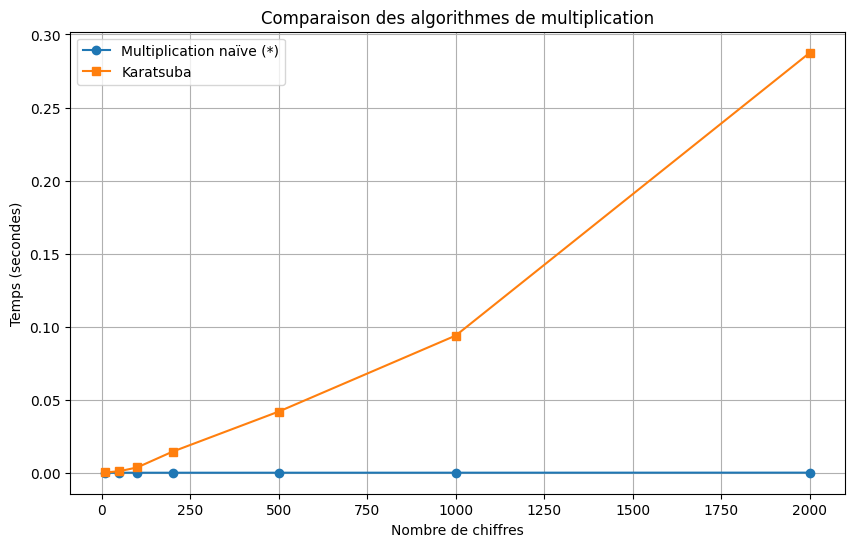

In [29]:
plt.figure(figsize=(10,6))
plt.plot(tailles, temps_naif, 'o-', label='Multiplication naïve (*)')
plt.plot(tailles, temps_karatsuba, 's-', label='Karatsuba')
plt.xlabel('Nombre de chiffres')
plt.ylabel('Temps (secondes)')
plt.title('Comparaison des algorithmes de multiplication')
plt.legend()
plt.grid(True)
plt.show()

**Question** : Pourquoi Karatsuba est-il parfois plus lent que la multiplication native pour de petites tailles ?

==> Les appels recursifs et les additions sont plus lourds avec des calcules simples

### 7.2 Comparaison des tris : tri fusion vs `sorted()`

On mesure sur des listes aléatoires de tailles croissantes.

In [30]:
tailles_listes = [1000, 2000, 5000, 10000, 20000, 50000]
temps_fusion = []
temps_sorted = []

for n in tailles_listes:
    liste = [random.randint(0, 1000000) for _ in range(n)]
    t_fus = timeit.timeit(lambda: tri_fusion(liste), number=3) / 3
    t_sor = timeit.timeit(lambda: sorted(liste), number=3) / 3
    temps_fusion.append(t_fus)
    temps_sorted.append(t_sor)
    print(f"n = {n:6d} : tri fusion = {t_fus:.4f}s, sorted = {t_sor:.4f}s")

n =   1000 : tri fusion = 0.0058s, sorted = 0.0002s
n =   2000 : tri fusion = 0.0119s, sorted = 0.0004s
n =   5000 : tri fusion = 0.0247s, sorted = 0.0011s
n =  10000 : tri fusion = 0.0663s, sorted = 0.0032s
n =  20000 : tri fusion = 0.1409s, sorted = 0.0060s
n =  50000 : tri fusion = 0.4899s, sorted = 0.0207s


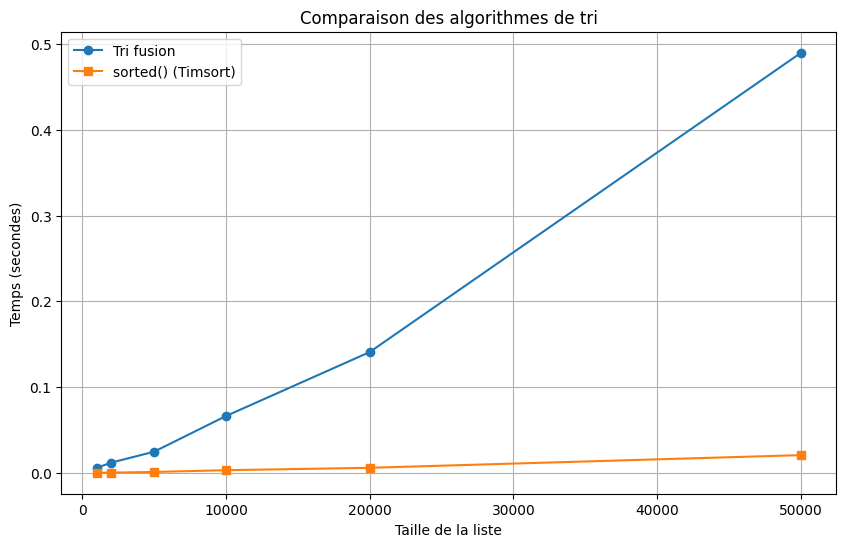

In [31]:
plt.figure(figsize=(10,6))
plt.plot(tailles_listes, temps_fusion, 'o-', label='Tri fusion')
plt.plot(tailles_listes, temps_sorted, 's-', label='sorted() (Timsort)')
plt.xlabel('Taille de la liste')
plt.ylabel('Temps (secondes)')
plt.title('Comparaison des algorithmes de tri')
plt.legend()
plt.grid(True)
plt.show()

**Remarque** : La fonction intégrée `sorted()` est implémentée en C et très optimisée, mais notre tri fusion reste un excellent exercice pédagogique.

## 8. Exercices supplémentaires

### 8.1 Recherche dichotomique (Binary Search)

Implémentez une version récursive de la recherche dichotomique.

In [32]:
def recherche_dicho_rec(liste_triee, element, debut=0, fin=None):
    """Recherche dichotomique récursive."""
    if fin is None:
        fin = len(liste_triee) - 1
    # Si fin inferieur que le debut, donc l' element n'est pas dans la liste et on arrete
    if fin < debut:
        return -1
    
    # calcul du milieu dependant de l'index du tableau, ex : debut = 4, et fin = 9, milieu = 7 
    milieu = (debut + fin) // 2
    # Si l' element est trouvé ,on arrete
    if liste_triee[milieu] == element:
        return milieu
    
    # On recherche l' element  a droite
    if liste_triee[milieu] < element:
        return recherche_dicho_rec(liste_triee, element, debut = milieu + 1, fin = fin)
    
    # On recherche l'element a gauche
    if liste_triee[milieu] > element:
        return recherche_dicho_rec(liste_triee, element, debut=debut, fin = milieu - 1)
    

In [33]:
# Test
liste_triee = [2, 5, 8, 12, 16, 23, 38, 56, 72, 91]
assert recherche_dicho_rec(liste_triee, 23) == 5
assert recherche_dicho_rec(liste_triee, 42) == -1
print("Test réussi !")

Test réussi !


### 8.2 Maximum d'une liste (Diviser pour Régner)

Implémentez une fonction qui trouve le maximum d'une liste en utilisant le paradigme « diviser pour régner ».

In [34]:
def fusion_max(gauche, droite):
    if gauche <= droite:
        return droite
    else:
        return gauche


def max_diviser_regner(liste):
    """Trouve le maximum d'une liste par diviser pour régner."""
    if len(liste) == 0:
        return -1 # pas de liste
    if len(liste) == 1:
        return liste[0]
    
    # meme raisonnement que la foction Trifusion mais ici, on compare juste les elements et retourner un seul element
    milieu = len(liste) // 2
    gauche = max_diviser_regner(liste[:milieu])
    droite = max_diviser_regner(liste[milieu:])
    return fusion_max(gauche, droite)

In [35]:
# Test
import random
liste_aleatoire = [random.randint(1, 1000) for _ in range(100)]
assert max_diviser_regner(liste_aleatoire) == max(liste_aleatoire)
print("Test réussi !")

Test réussi !


### 8.3 Tours de Hanoï

Le problème des Tours de Hanoï est un classique de la récursivité.

In [36]:
def hanoi(n, source, destination, auxiliaire):
    """Affiche les déplacements pour résoudre les Tours de Hanoï."""
    if n == 1:
        print(f"Déplacer disque 1 de {source} vers {destination}")
    else:
        # Votre code ici
        # On deplace les n-1 disque vers l auxiliaire pour liberer le plus grand disque (n) de MANIERE RECURSIVE
        hanoi(n-1,source, auxiliaire, destination)
        # On deplace le plus grand disque vers la destination
        print(f"Déplacer disque {n} de {source} vers {destination}")
        # On deplace apres les n-1 disque d'auxiliaire vers la destination au dessus du (n) disque de MANIERE RECURSIVE
        hanoi(n-1, auxiliaire, destination, source)


# Test avec n=3
print("Résolution pour 3 disques :")
hanoi(3, 'A', 'C', 'B')

Résolution pour 3 disques :
Déplacer disque 1 de A vers C
Déplacer disque 2 de A vers B
Déplacer disque 1 de C vers B
Déplacer disque 3 de A vers C
Déplacer disque 1 de B vers A
Déplacer disque 2 de B vers C
Déplacer disque 1 de A vers C


### 8.4 Exercice avancé : Multiplication de polynômes par Karatsuba

Créez une classe `Polynome` qui représente un polynôme par la liste de ses coefficients. Implémentez la multiplication de deux polynômes en utilisant l'algorithme de Karatsuba (inspiré du cours CS320 de Colorado State University[reference:15]).

In [37]:
class PolynomeAvance:
    def __init__(self, coefficients):
        self.coeffs = coefficients[:]
        self._nettoyer()
    
    def _nettoyer(self):
        while len(self.coeffs) > 1 and self.coeffs[-1] == 0:
            self.coeffs.pop()
    
    def __add__(self, other):
        max_len = max(len(self.coeffs), len(other.coeffs))
        new_coeffs = []
        for i in range(max_len):
            c1 = self.coeffs[i] if i < len(self.coeffs) else 0
            c2 = other.coeffs[i] if i < len(other.coeffs) else 0
            new_coeffs.append(c1 + c2)
        return PolynomeAvance(new_coeffs)
    
    def __sub__(self, other):
        max_len = max(len(self.coeffs), len(other.coeffs))
        new_coeffs = []
        for i in range(max_len):
            c1 = self.coeffs[i] if i < len(self.coeffs) else 0
            c2 = other.coeffs[i] if i < len(other.coeffs) else 0
            new_coeffs.append(c1 - c2)
        return PolynomeAvance(new_coeffs)
    
    def __mul__(self, other):
        """Multiplication par Karatsuba (à implémenter)."""

        n = max(len(self.coeffs), len(other.coeffs))

        # On egalise les tailles des deux polynomes en ajoutant 0 aux coeffs manquantes
        self.coeffs += [0] * (n - len(self.coeffs))
        other.coeffs += [0] * (n - len(other.coeffs))

        if n == 1:
            return PolynomeAvance([self.coeffs[0] * other.coeffs[0]])
        
        m = (n ) // 2

        # On divise en deux les listes de coefficients, comme on a fait aux nombres entiers auparavent 
        # ex: 143635 => a = 143 et b = 635, ici [1, 4, 3, 6, 3, 5] => ex: n = 6, on a [1, 4, 3] et [6, 3, 5]
        P0 = PolynomeAvance(self.coeffs[:m])
        P1 = PolynomeAvance(self.coeffs[m:])
        Q0 = PolynomeAvance(other.coeffs[:m])
        Q1 = PolynomeAvance(other.coeffs[m:])

        # 3 appels récursifs (* appelle __mul__ automatiquement de meme pour +, - qui appellent __add__, et resp __sub__)
        Z0 = P0 * Q0
        Z1 = P1 * Q1
        Z2 = (P0 + P1) * (Q0 + Q1) - Z0 - Z1

        # Décalages pour Z1 et Z2 on a par exemple
        # on a de base Z1*x^2m + Z2*x^m + Z0
        # si m = 2 par exemple  Z2 = [3, 5] on doit avoir Z2* X^2 = [0, 0, 3, 5]
        # de meme pour Z1 = [1, 2], m = 2 ==> Z1 *X^4 = [0, 0, 0, 0, 1, 2]
        Z1 = PolynomeAvance([0] * 2*m + Z1.coeffs)
        Z2 = PolynomeAvance([0] * m + Z2.coeffs)


        return Z1 + Z2 + Z0
    
    def __str__(self):
        terms = []
        for i, c in enumerate(self.coeffs):
            if c != 0:
                if i == 0:
                    terms.append(str(c))
                elif i == 1:
                    terms.append(f"{c}x")
                else:
                    terms.append(f"{c}x^{i}")
        return " + ".join(terms) if terms else "0"

In [38]:
# Test
p1 = PolynomeAvance([1, 2, 3])  # 1 + 2x + 3x^2
p2 = PolynomeAvance([2, 1])     # 2 + x

# Résultat attendu : 2 + 5x + 8x^2 + 3x^3
print(p1 * p2)


2 + 5x + 8x^2 + 3x^3


## 9. Rendu et commit GitHub

1. Complétez les parties manquantes du notebook (exercices).
2. Assurez-vous que toutes les cellules s'exécutent sans erreur.
3. Ajoutez des commentaires expliquant vos choix d'implémentation.
4. Commitez ce notebook dans votre dépôt GitHub sous le nom `seance2.ipynb`.
5. Mettez à jour le fichier `README.md` avec une brève description des algorithmes implémentés.

**Rappel** : L'utilisation d'assistants IA est permise, mais vous devez être capable d'expliquer chaque ligne de code et de justifier l'analyse de complexité.

---

**Références** :
- Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C. *Introduction to Algorithms*, 4th ed. MIT Press, 2022.
- Sedgewick, R., & Wayne, K. *Algorithms*, 4th ed. Addison-Wesley, 2011.
- MIT OpenCourseWare 6.006, Lectures 3-4.
- Stanford CS161, Lecture 3.
- Princeton Algorithms (Coursera), Week 3.
- Harvard CS50, Week 3.